# 1. Phage display: FXIa selection

This notebook demonstrates the use of clibas to analyze phage display library selections using data from Heinis and co-workers as an example.<br>

For further details and the source of data, see [X. Kong _et al_. De novo development of proteolytically resistant therapeutic peptides for oral administration. _Nat Biomed Eng_ **2020**, 4, 560–571](https://www.nature.com/articles/s41551-020-0556-3)

In the paper, the authors design and screen sophisticated bicyclic peptide libraries containing four cysteine residues separated by random regions of variable length and configuration against Factor XIa protein (FXIa). See Fig. 1C from the original paper (reproduced below):

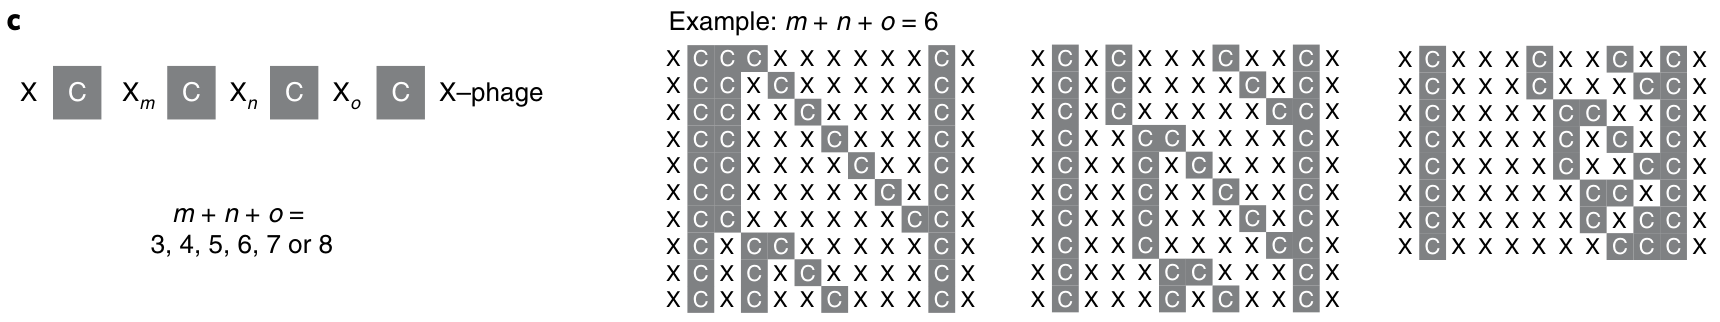

The libraries were additionally cyclized with external electrophilic linkers, but their identity is not encoded in the NGS data, so we will only analyze peptide sequences here.

The NGS-derived DNA reads, once aligned, look something like this:

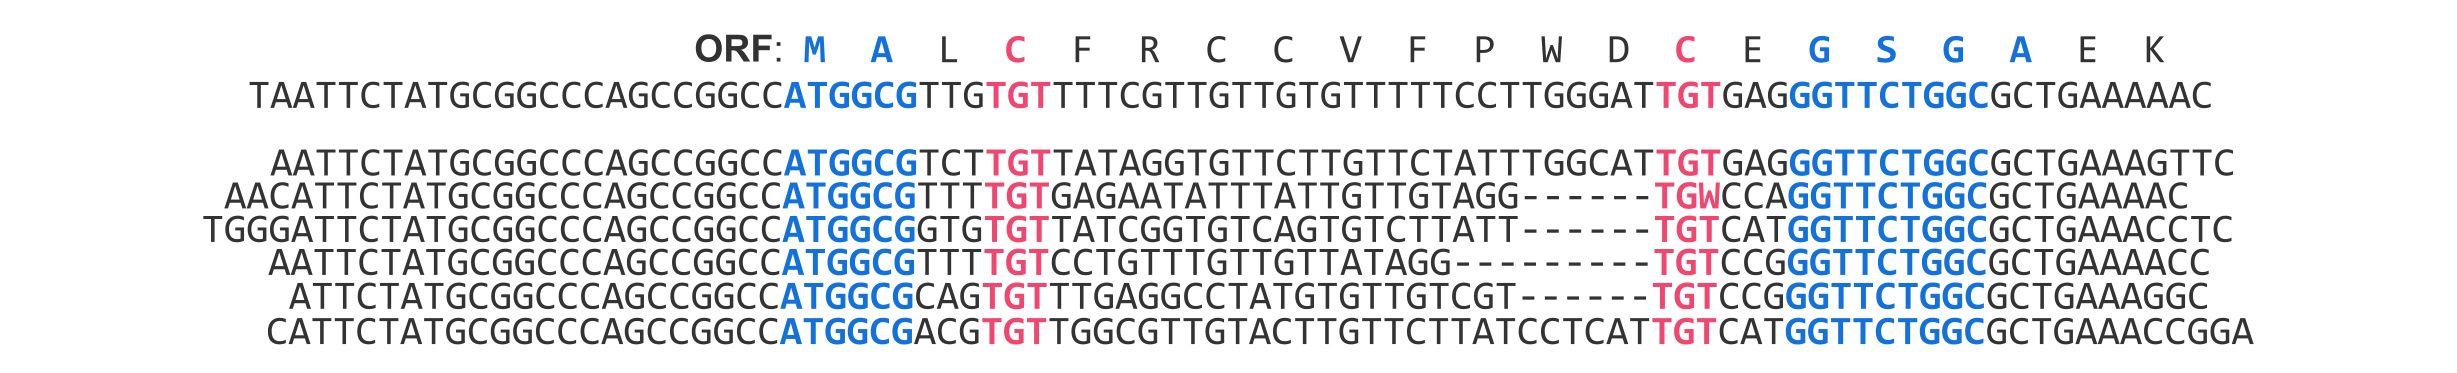

The reads, provided in single-end format, have variable lengths. They all have constant regions flanking the library insert on the N- ("MA") and C-terminal ("GSGA...") sides. These variable-length reads are not easy to deal with. To simplify the analysis, we can trim them to the constant regions as the first operation in the pipeline. DNA and peptide library designs for a clibas pipeline can then be written like this:  

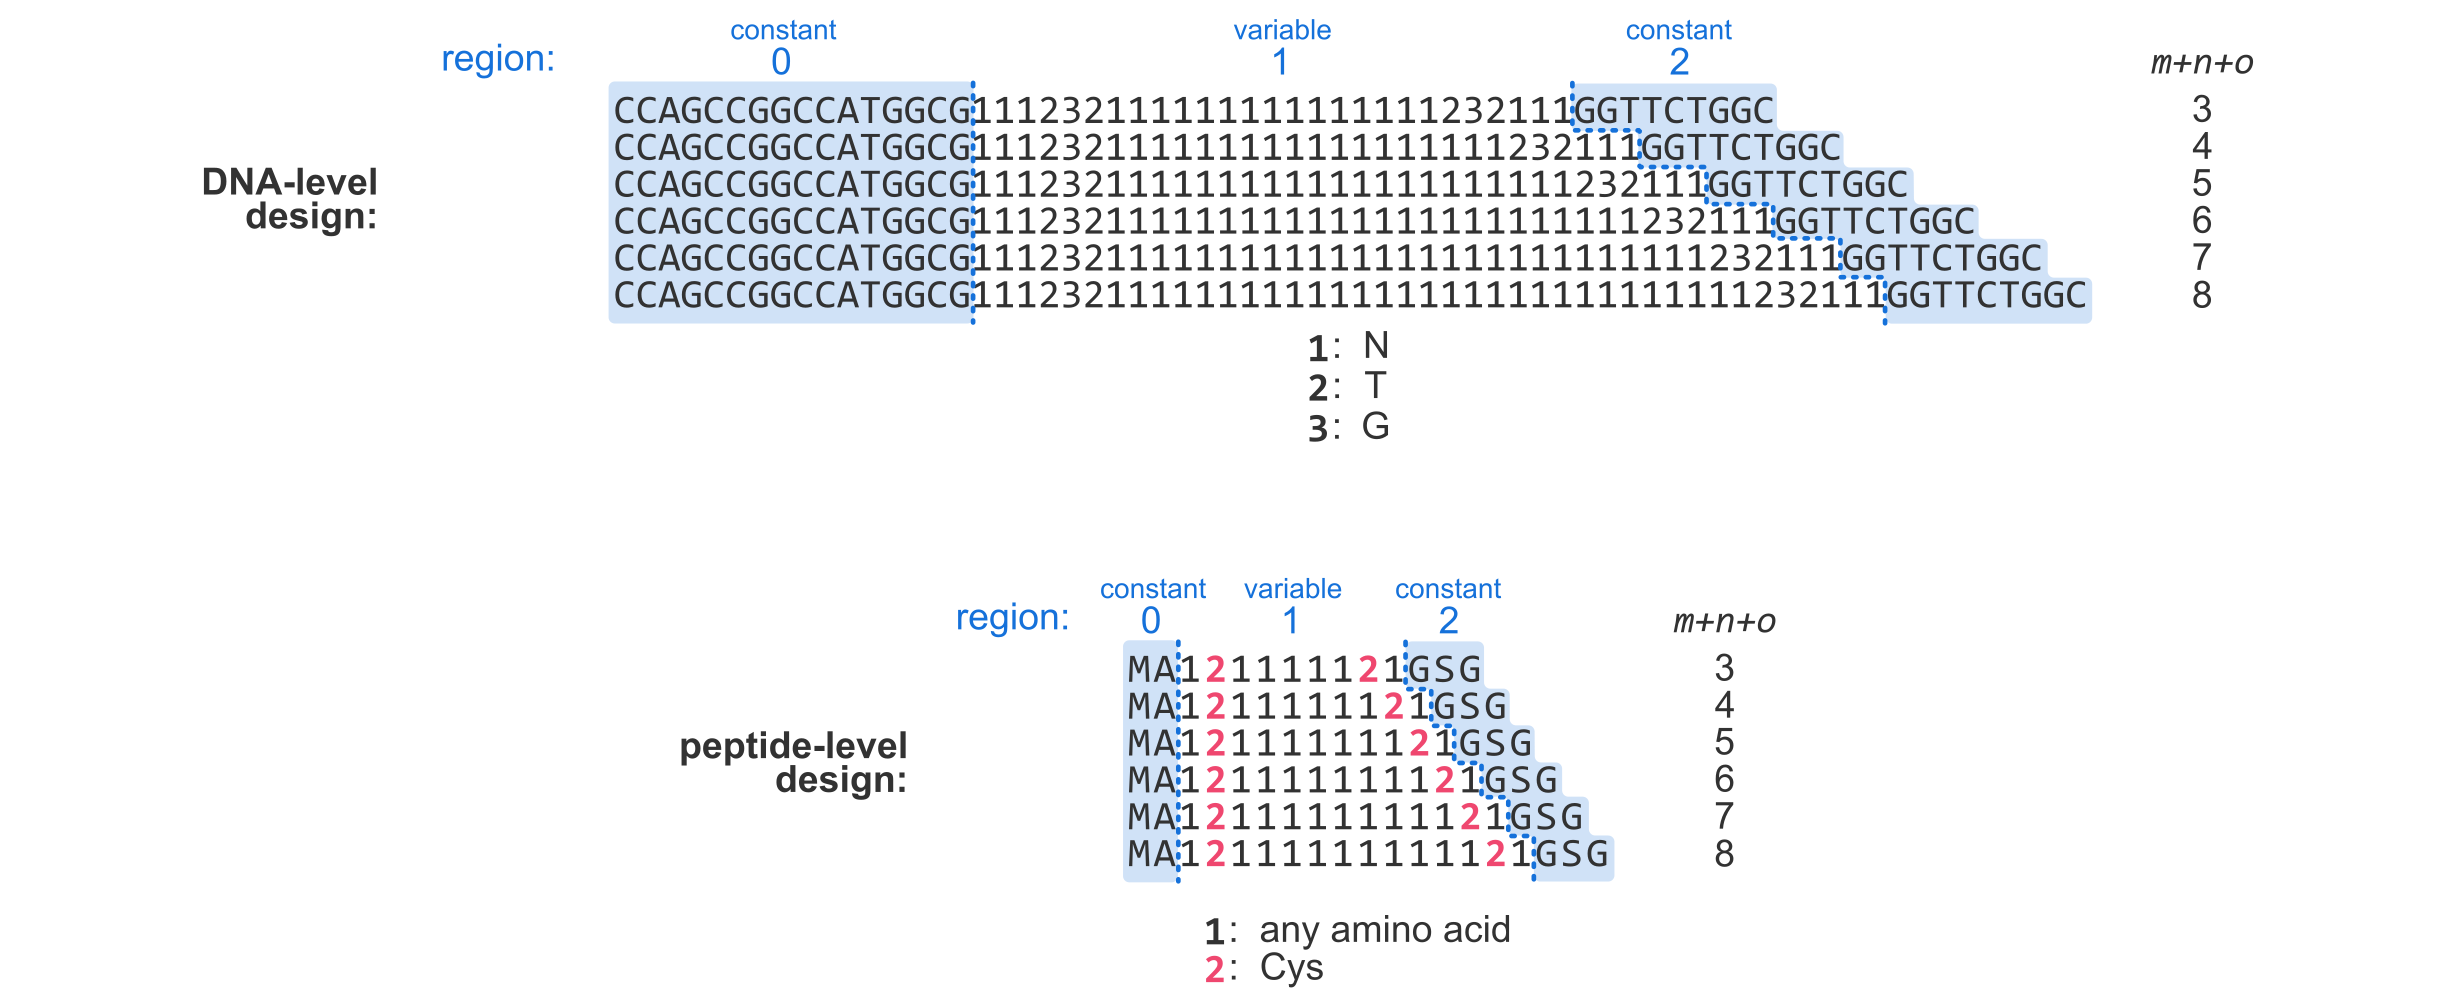

These designs generally work, but they don't enforce two additional cysteines present in each peptide. Some peptides that only contain 2 or 3 cysteine residues will also be captured by downstream filtering. If this is to be avoided, every (m+n+o) combination of cysteines inside the insert can be spelled out as a separate template. Here, we opt for simplicity and lump them all together.

A `.yaml` config file can then be written accordingly:

```yaml
experiment: "Heinis_FXIa_selection"

LibraryDesigns:
  dna_templates:
    - "CCAGCCGGCCATGGCG111232111111111111111232111GGTTCTGGC"
    - "CCAGCCGGCCATGGCG111232111111111111111111232111GGTTCTGGC"
    - "CCAGCCGGCCATGGCG111232111111111111111111111232111GGTTCTGGC"
    - "CCAGCCGGCCATGGCG111232111111111111111111111111232111GGTTCTGGC"
    - "CCAGCCGGCCATGGCG111232111111111111111111111111111232111GGTTCTGGC"
    - "CCAGCCGGCCATGGCG111232111111111111111111111111111111232111GGTTCTGGC"
    
  dna_monomers:
    1: ["A", "G", "T", "C"] #N
    2: ["T"]
    3: ["G"]
    
  pep_templates:
    - "MA121111121GSG"
    - "MA1211111121GSG"
    - "MA12111111121GSG"
    - "MA121111111121GSG"
    - "MA1211111111121GSG"
    - "MA12111111111121GSG"
 
  pep_monomers:
    1: ["A", "C", "D", "E", "F", "G", "H", "I", "K", "L", "M", "N", "P", "Q", "R", "S", "T", "V", "W", "Y"]
    2: ["C"]

FastqParserConfig:
  orf_locator: "GGC.ATG"            # A regex pattern that has to match to initiate the ORF 

TrackerConfig:
  logs: "./outputs/Heinis_FXIa"                 # Directory for writing logs to
  parser_out: "./outputs/Heinis_FXIa"           # Directory that stores fastq parser outputs
  analysis_out: "./outputs/Heinis_FXIa"         # Directory that stores outputs of data analysis operations
  
LoggerConfig:
  verbose: true                     # Verbose loggers print to the console
  log_to_file: false                # Write logs to file
  level: "INFO"                     # Logger level; accepted values: "DEBUG", "INFO", "WARNING", "ERROR"
```

In addition to `LibraryDesigns`, we also specify `orf_locator`: `"GGC.ATG"`. This helps the parser locate the ORF at the 5' end of the reads. This is optional. If not specified, `"ATG"` will be used to locate ORFs which works fine most of the time. `TrackerConfig` and `LoggerConfig` specifications are also optional. 

To build a pipeline for these designs, we first intialize clibas facade using this config file:

In [1]:
import clibas as C

C.initialize(config_path="Heinis_FXIa_config.yaml")

[WARNING]: <Dispatcher>: config is missing some basic definitions (bases, amino acids, translation tables, etc); will use defaults for the missing values. . . 
[INFO]: <clibas> succesfully loaded config and is ready. . .


Now we can build the pipeline. As explained above, we trim the reads first, translate them to DNA right after, and process from there. 
A few things to note:

> i) we collect DNA/peptide lengths before doing any filtering to see an unbiased distribution of reads.
>  
> ii) the `count_summary` operation is called multiple times:  
> - first, before doing any filtering to see the initial (raw) composition of the library at the peptide level 
> - then at the end, after removing noise, to generate both `.csv` and `.fasta` files for the most enriched peptides.
> 
> iii) we call `umap_hdbscan_analysis` to see how the resulting peptides cluster after all processing is done. It is discussed in more detail below. 

In [2]:
C.pipeline.enque(
    [
        # trim DNA reads
        C.fastq_parser.trim_reads(left="CCAGCC", right="GGTTCTGGC", tol=1),
        # translate DNA -> peptide, use the ORF_locator to find ORFs
        C.fastq_parser.translate(stop_readthrough=False),
        # length analysis of trimmed DNA reads and the resulting peptides
        # we do it before filtering any reads to get an unbiased view
        C.analysis_tools.length_analysis(where="pep"),
        C.analysis_tools.length_analysis(where="dna"),
        # analyze average Phred quality scores
        # we do it before filtering any reads to get an unbiased view
        C.analysis_tools.q_score_analysis(loc=None),
        # count the peptides before doing any filtrtion
        C.fastq_parser.count_summary(where="pep", top_n=1000, fmt="csv"),
        # discard the peptides of incorrect length (incompatible with library designs)
        C.fastq_parser.len_filter(where="pep"),
        # discard the peptides with incorrect/overly mutated constant regions
        # up to 2 mutations are tolerated
        C.fastq_parser.cr_filter(where="pep", loc=[0, 2], tol=2),
        # discard the peptides contained unallowed monomers in the variable region
        C.fastq_parser.vr_filter(where="pep", loc=[1], sets=[1, 2]),
        # discard the peptides containing Q scores below 30 in region 1 (random insert region)
        C.fastq_parser.q_score_filt(minQ=30, loc=[1]),
        # clip peptide sequences to region 1 (random insert region)
        C.fastq_parser.fetch_at(where="pep", loc=[1]),
        # discard all peptides containing any ambiguous amino acids
        # stemming from N nucleotide base calling etc
        C.fastq_parser.filt_ambiguous(where="pep"),
        # analyze the convergence of the peptide library at the sequence level
        C.analysis_tools.sequence_convergence_analysis(where="pep"),
        # analyze the convergence of the peptide/DNA library at the token level
        # by token, we mean amino acid/nucleotide: basically positional freq analysis
        C.analysis_tools.token_convergence_analysis(where="pep", loc=None),
        C.analysis_tools.token_convergence_analysis(where="dna", loc=None),
        # unpad all arrays: optional, maybe used to free up some memory; not srictly needed in this case
        C.fastq_parser.unpad(),
        # save the peptide datasets as numpy .npy files
        C.fastq_parser.save(where="pep", fmt="npy"),
        # count peptides/DNA again - this time after all filtration ops have been called
        C.fastq_parser.count_summary(where="pep", top_n=1000, fmt="csv"),
        C.fastq_parser.count_summary(where="pep", top_n=100, fmt="fasta"),
        C.fastq_parser.count_summary(where="dna", top_n=1000, fmt="csv"),
        C.fastq_parser.count_summary(where="dna", top_n=100, fmt="fasta"),
        # make a table showing the number of reads belonging to each individual
        # library template for every sample in the batch
        C.fastq_parser.library_design_match(where="pep"),
        # make one joint peptide count summary - track peptides from sample to sample
        C.fastq_parser.dataset_wide_count_summary(where="pep", top_n=2000),
        # run UMAP/HDBSCAN analysis on top 1000 peptides; use ECFP4 representation,
        # and embed all samples onto a single manifold to enable direct comparisons
        C.analysis_tools.umap_hdbscan_analysis(
            top_n=1000,
            where="pep",
            F="pep_ECFP4",
            single_manifold=True,
            return_modified=True,
        ),
    ]
)

[INFO]: 24 ops appended to pipeline; current queue size: 24


Note that at this stage, no data processing has taken place. The pipeline only asserts the validity of the arguments, and their consistency with the specified library designs.

To run analysis, we need to specify a data loader, and then execute the pipeline:

In [3]:
"""run everything from the specified folder together in memory"""
loader = C.data_loader.fetch_fastq_from_dir(data_dir="./sequencing_data/Heinis_FXIa")
data = C.pipeline.load_and_run(loader=loader, save_summary=True)

[INFO]: Queuing <fetch_dir_fastq> op. . .
[INFO]: Fetching FXIa_Round2_Linker7.fastq. . .
[INFO]: Fetching FXIa_Round3_Linker7.fastq. . .
[INFO]: Fetching FXIa_Round5_Linker7_0pSIF.fastq. . .
[INFO]: Fetching FXIa_Round5_Linker7_10pSIF.fastq. . .
[INFO]: Fetching FXIa_Round5_Linker7_1pSIF.fastq. . .
[INFO]: Fetching FXIa_Round6_Linker7_0pSIF.fastq. . .
[INFO]: Fetching FXIa_Round6_Linker7_10pSIF.fastq. . .
[INFO]: Fetching FXIa_Round6_Linker7_1pSIF.fastq. . .
[INFO]: The operation took 30.495 s
[INFO]: FXIa_Round2_Linker7 dataset size: 2928254
[INFO]: FXIa_Round3_Linker7 dataset size: 2335880
[INFO]: FXIa_Round5_Linker7_0pSIF dataset size: 2007008
[INFO]: FXIa_Round5_Linker7_10pSIF dataset size: 2072144
[INFO]: FXIa_Round5_Linker7_1pSIF dataset size: 2163954
[INFO]: FXIa_Round6_Linker7_0pSIF dataset size: 1973700
[INFO]: FXIa_Round6_Linker7_10pSIF dataset size: 1755820
[INFO]: FXIa_Round6_Linker7_1pSIF dataset size: 2256214
[INFO]: ------------------------------------------------------

That's it: all pipeline outputs were written to a directory specified in the config file (`.outputs/Heinis_FXIa` in this case). The code below highlights certain outputs, but isn't integral to the pipeline.

The `INFO` logger stream above is summarized in a pipeline summary file because we ran it with `save_summary=True`. It is saved in the `logs` folder as specified in the config file. We can load the resulting summary here:

In [4]:
from pathlib import Path

import pandas as pd

out_dir = C.fastq_parser.dirs.logs
exp_name = C.fastq_parser.exp_name

fname = next(Path(out_dir).glob(f"{exp_name}_pipeline_summary*.csv"))
summary = pd.read_csv(fname)

In [5]:
summary

,Unnamed: 0,"elapsed time, s",FXIa_Round2_Linker7,FXIa_Round6_Linker7_10pSIF,FXIa_Round6_Linker7_1pSIF,FXIa_Round5_Linker7_1pSIF,FXIa_Round6_Linker7_0pSIF,FXIa_Round5_Linker7_10pSIF,FXIa_Round5_Linker7_0pSIF,FXIa_Round3_Linker7
0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,fetch_dir_fastq,30.495,2928254.0,1755820.0,2256214.0,2163954.0,1973700.0,2072144.0,2007008.0,2335880.0
2,trim_exp,35.055,2928254.0,1755820.0,2256214.0,2163954.0,1973700.0,2072144.0,2007008.0,2335880.0
3,translate_dna,81.158,2928254.0,1755820.0,2256214.0,2163954.0,1973700.0,2072144.0,2007008.0,2335880.0
4,length_summary,9.014,2928254.0,1755820.0,2256214.0,2163954.0,1973700.0,2072144.0,2007008.0,2335880.0
5,length_summary,29.245,2928254.0,1755820.0,2256214.0,2163954.0,1973700.0,2072144.0,2007008.0,2335880.0
6,q_score_summary,51.637,2928254.0,1755820.0,2256214.0,2163954.0,1973700.0,2072144.0,2007008.0,2335880.0
7,fastq_count_summary,9.000,2928254.0,1755820.0,2256214.0,2163954.0,1973700.0,2072144.0,2007008.0,2335880.0
8,length_filter,9.904,2546300.0,1717148.0,2204474.0,2114460.0,1925594.0,2024024.0,1960558.0,1874623.0
9,constant_region_filter,3.729,2529394.0,1707891.0,2193803.0,2104087.0,1916184.0,2012821.0,1950872.0,1847468.0


The numbers in the cells are read counts after the corresponding operation is completed. 

In [6]:
print(f"The entire pipeline took: {summary['elapsed time, s'].sum() / 60:.2f} min")

The entire pipeline took: 19.42 min


We can similarly take a look at other tables/plots that were generated. For example, the distribution of peptide (ORF) lengths in the initial dataset is as follows.

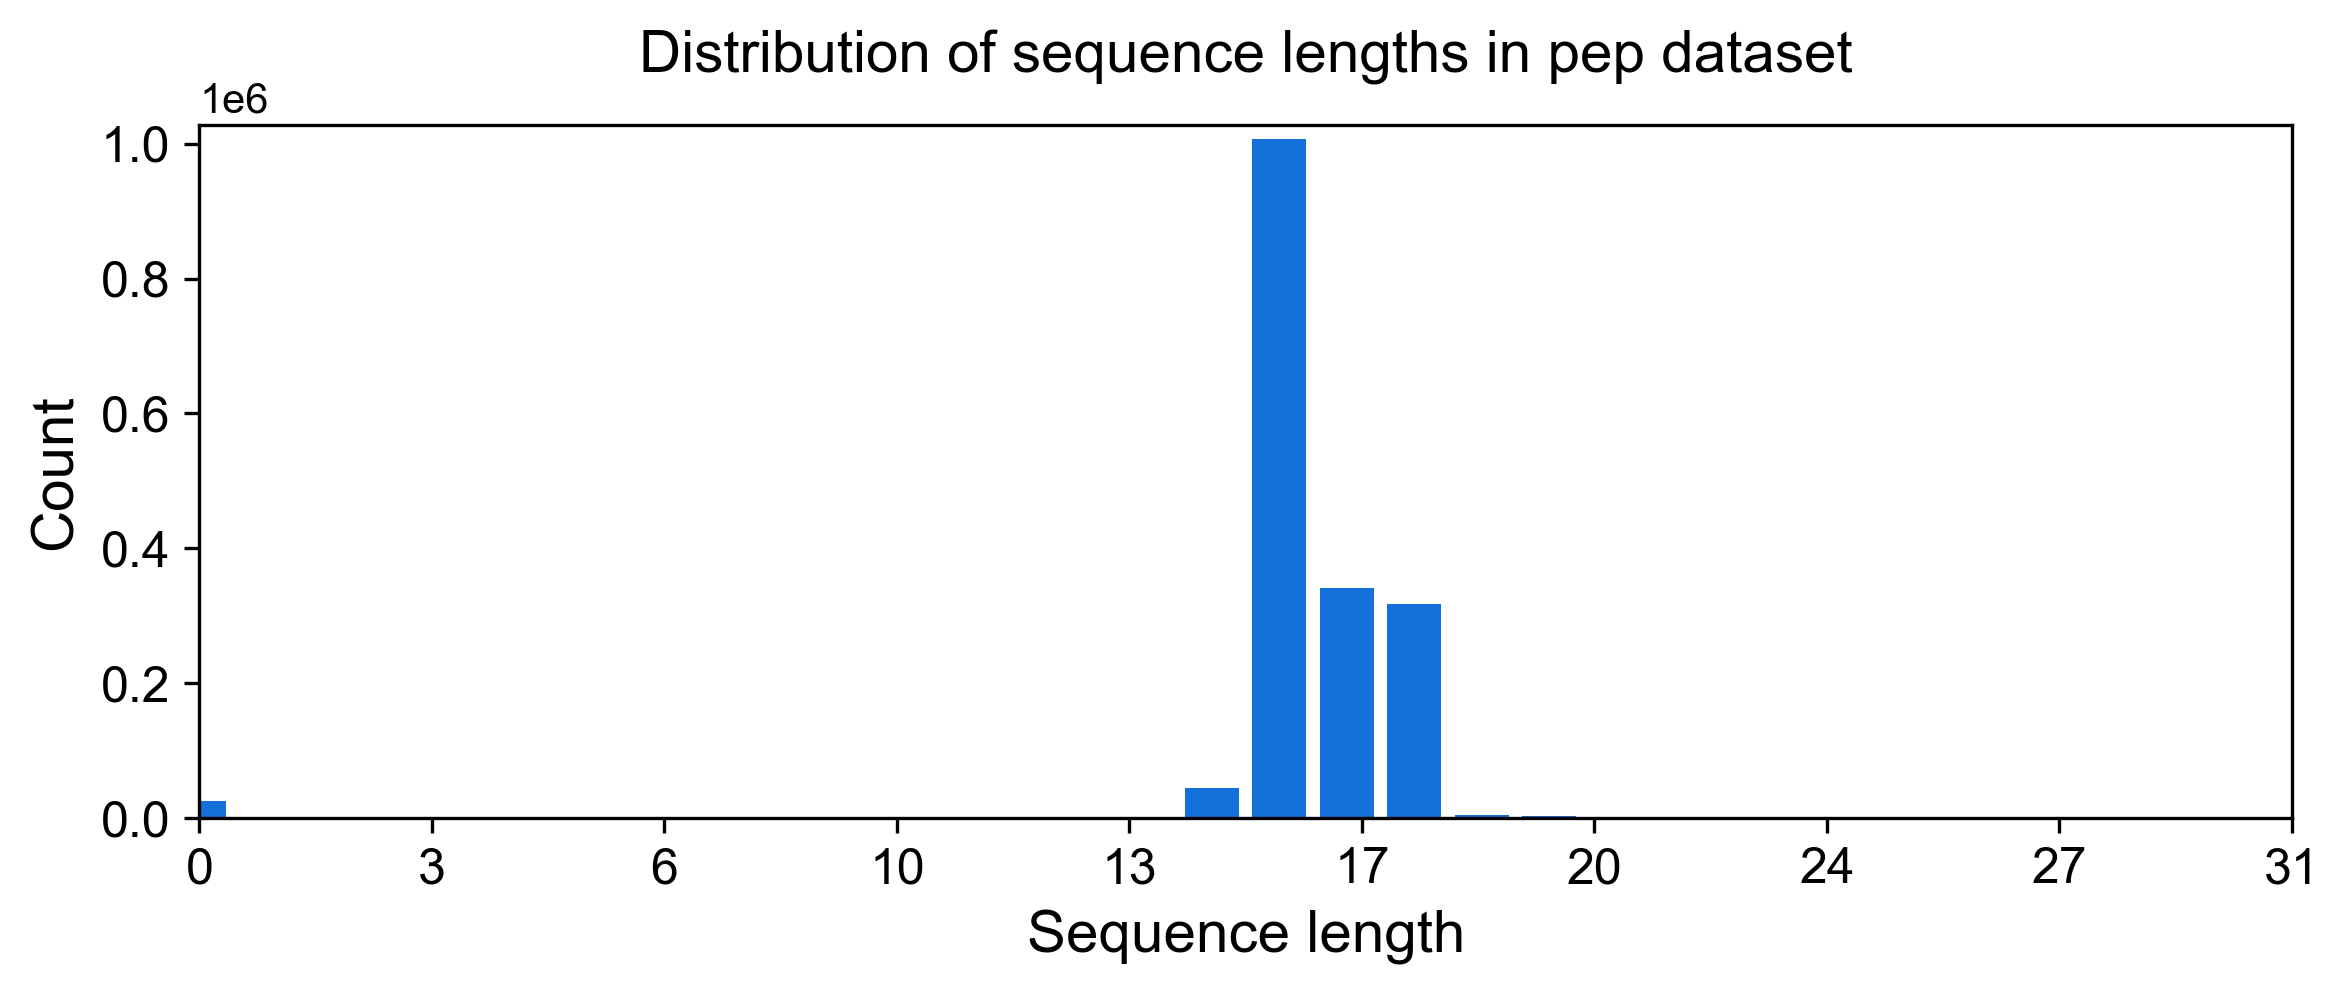

In [7]:
from IPython.display import Image, display

# for round 6 / linker 7 / 10% SIF selection data:
sample_name = "FXIa_Round6_Linker7_10pSIF"
out_dir = Path(out_dir) / sample_name
fname = next(Path(out_dir).glob(f"{sample_name}_pep_L_distribution*.png"))

display(Image(filename=fname, width=800))

DNA read lengths can be looked at analogously:

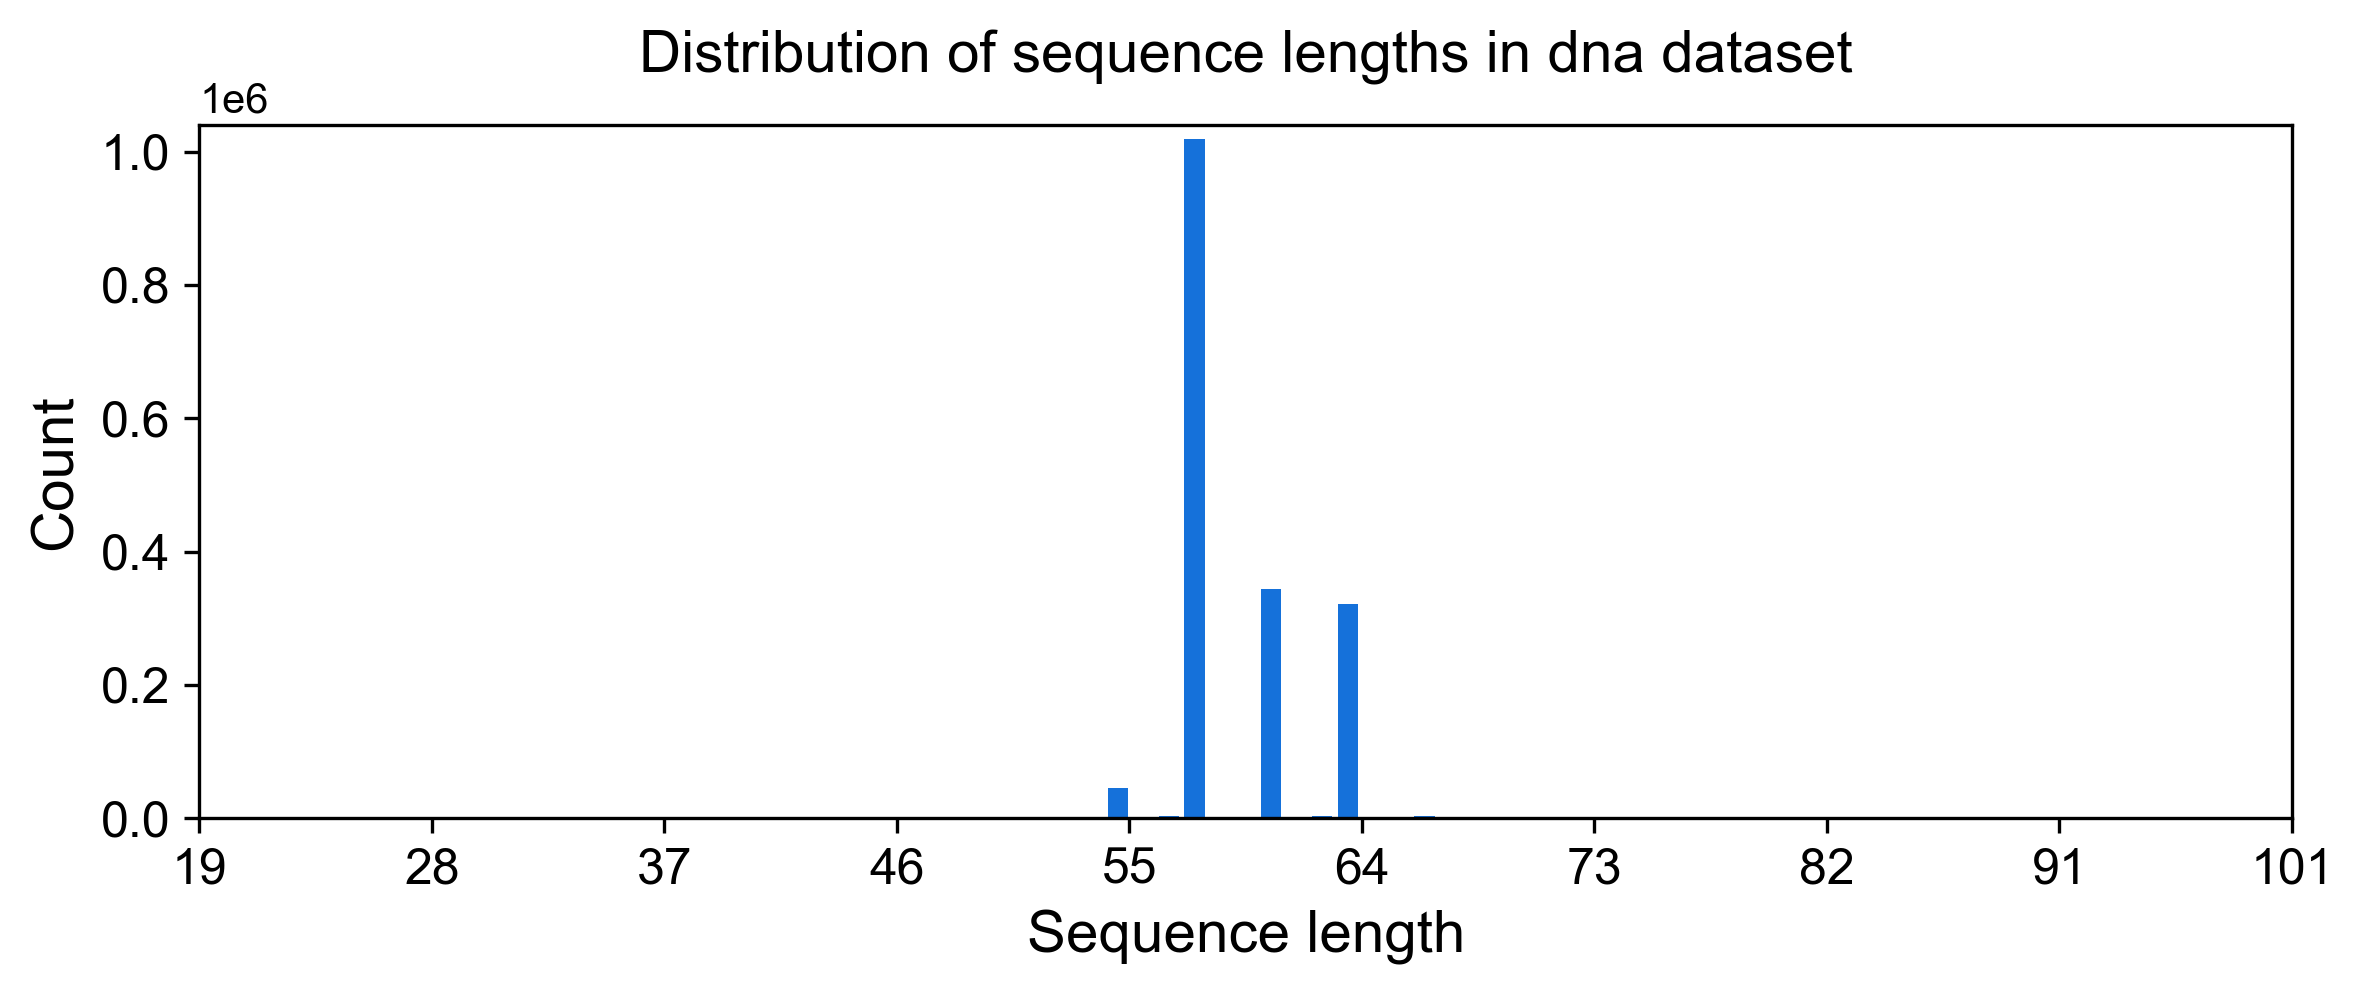

In [8]:
fname = next(Path(out_dir).glob(f"{sample_name}_dna_L_distribution*.png"))
display(Image(filename=fname, width=800))

Likewise, we collected the information about average positional Q score statistics:

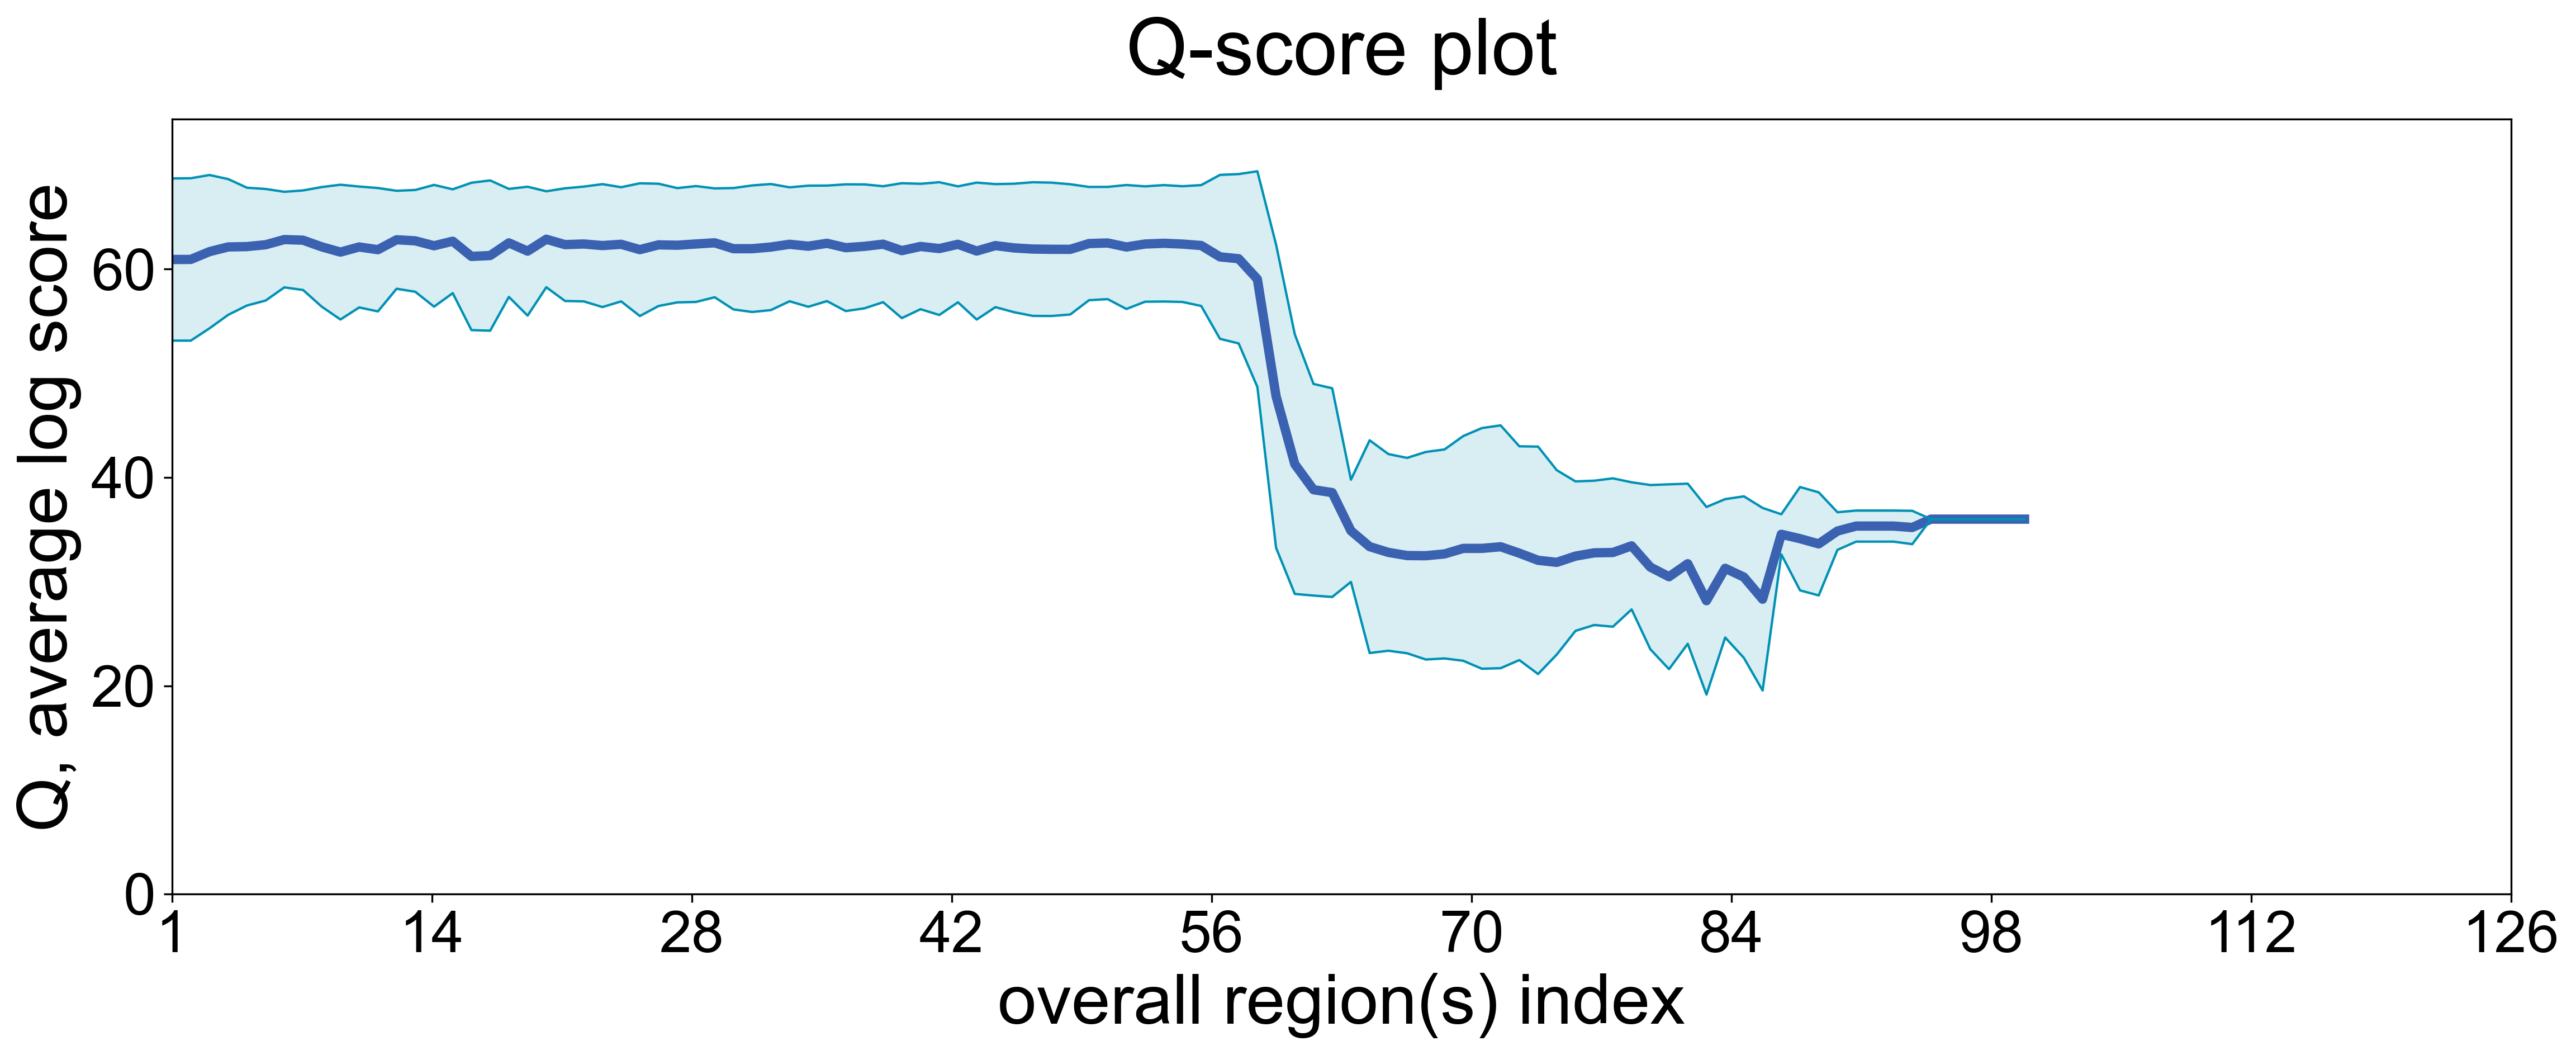

In [9]:
fname = next(Path(out_dir).glob(f"{sample_name}_q_score_summary*.png"))
display(Image(filename=fname, width=800))

The drop after ~56 nucleotides is likely a sequencing artifact: most real, sample-derived reads in this case are ~55-65 nt.

Convergence of the library at the sequence level is shown in a percentile plot:

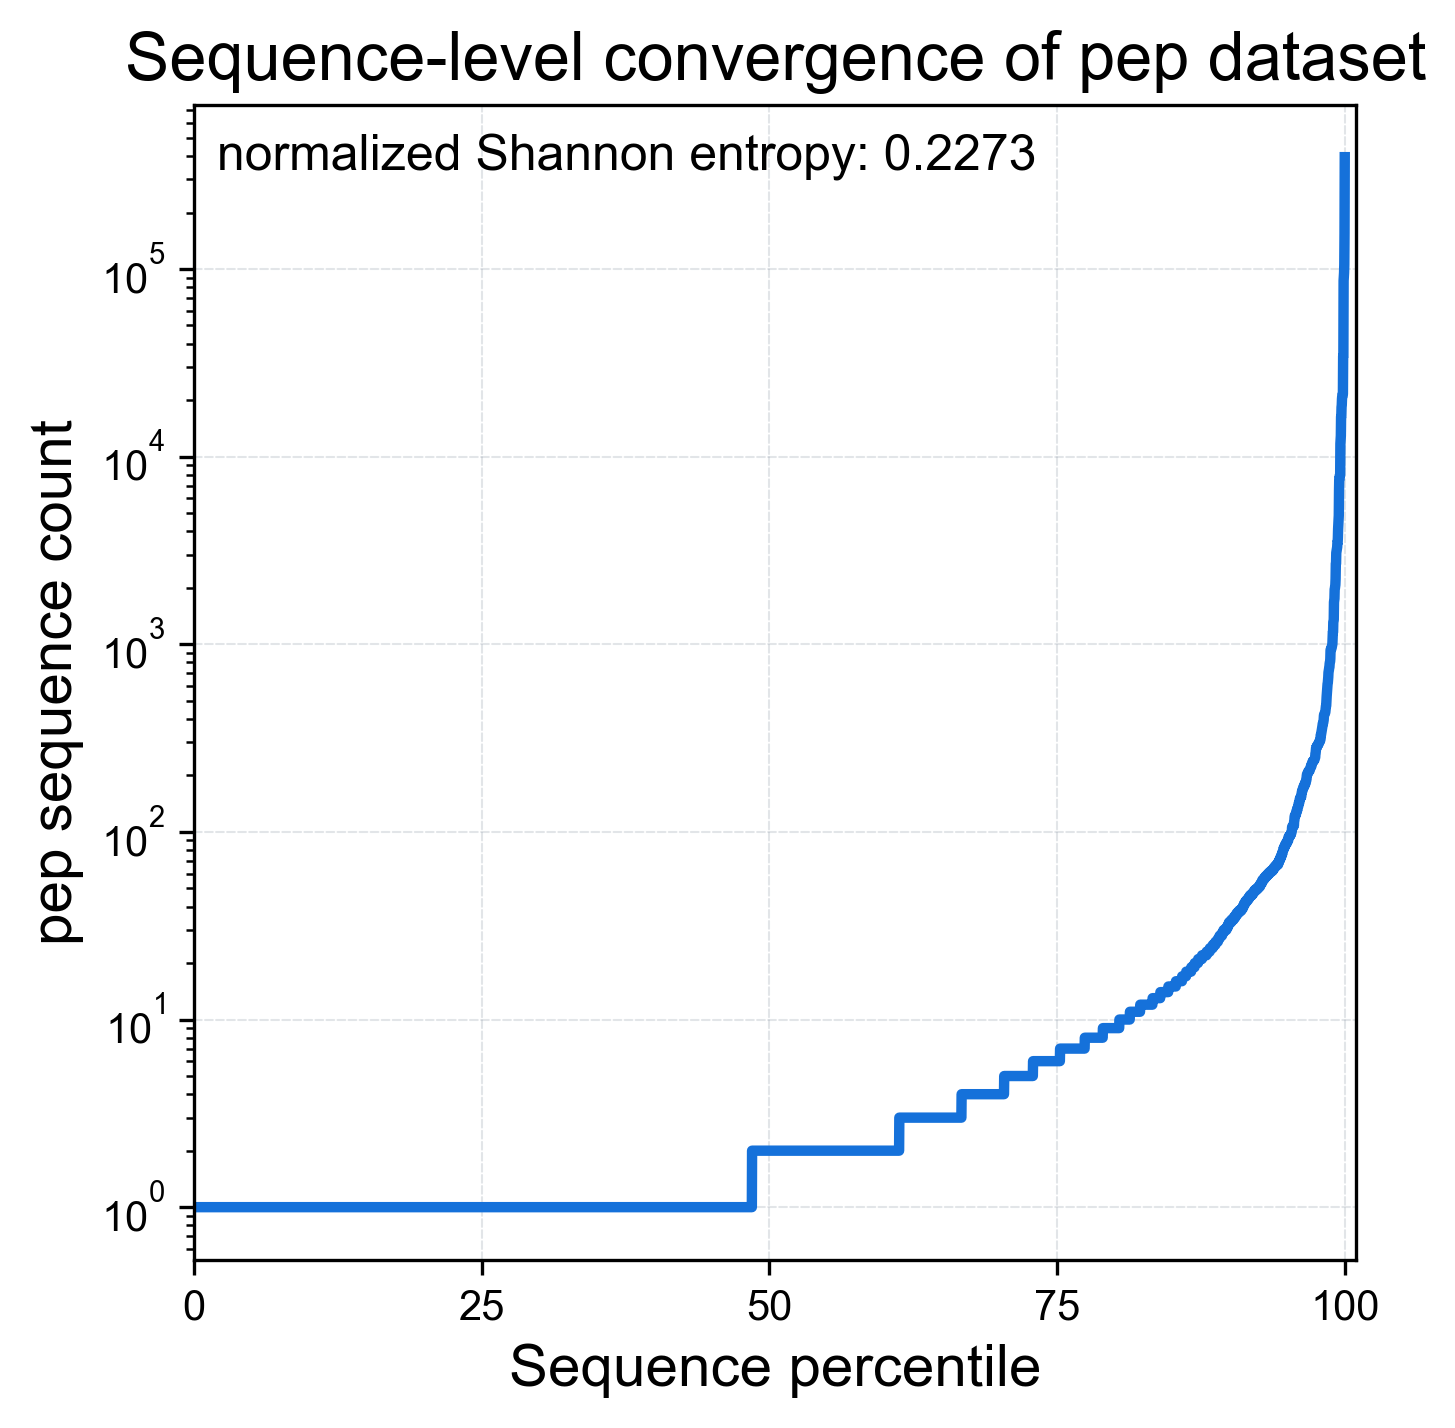

In [10]:
fname = next(Path(out_dir).glob(f"{sample_name}_pep_library_convergence*.png"))
display(Image(filename=fname, width=600))

The percentile plot shows that ~50% of all unique peptide sequences only appear in this dataset once (1 read; 10<sup>0</sup> counts). By contrast, top 1 (>99.99% percentile) peptide has over 10<sup>5</sup> reads. Library convergence can be quantified using [normalized Shannon entropy](https://en.wikipedia.org/wiki/Entropy_(information_theory)#Efficiency_(normalized_entropy)) (also called "efficiency"): a dataset consisting of one sequence repeating N times has normalized Shannon entropy of 0 (perfectly converged). Conversely, a dataset where each sequence is unique and has 1 count has normalized Shannon entropy of 1 (perfectly random). This dataset's 0.2273 indicates strong convergence to a small pool of sequences.

We also collected the information about the convergence at the token (amino acid) level in the form of a sequence logo. However, because in this paper the library was a combination of several sub-libraries of different designs, this overall, crude convergence analysis is of limited utility here:

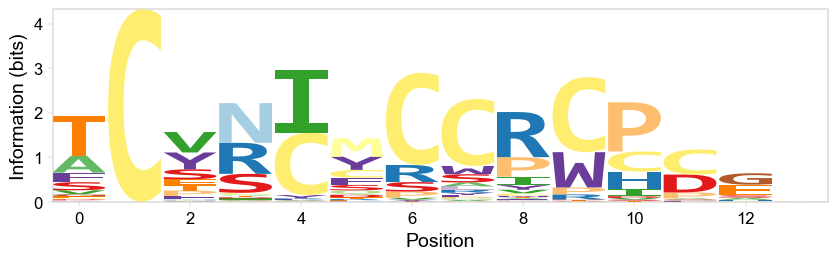

In [11]:
fname = next(Path(out_dir).glob(f"{sample_name}_pep_reg_overall_seq_logo*.png"))
display(Image(filename=fname, width=800))

Probably the most useful output is the count summary for peptides. We have created two of these - one before doing any data filtration, and one after.

In [12]:
fnames = list(Path(out_dir).glob(f"{sample_name}_pep_count_summary*.csv"))
fnames

[WindowsPath('outputs/Heinis_FXIa/FXIa_Round6_Linker7_10pSIF/FXIa_Round6_Linker7_10pSIF_pep_count_summary_2026_3_24_1_44_15.csv'),
 WindowsPath('outputs/Heinis_FXIa/FXIa_Round6_Linker7_10pSIF/FXIa_Round6_Linker7_10pSIF_pep_count_summary_2026_3_24_1_51_37.csv')]

All output file names are time-stamped for differentiation. Let's first take a look at the pre-filtration summary (`_2025_10_26_21_25_54` - the earlier of the two):

In [13]:
pre = pd.read_csv(fnames[0])
pre.head(20)

,Index,Peptide,DNA,pep count,Dataset %
0,1,MATCVNIMCCRCPGSG,CCAGCTGGCCATGGCGACGTGTGTGAATATTATGTGTTGTCGGTGT...,449023,25.573407
1,2,MAACSSCYRCPWCDGSG,CCAGCCGGCCATGGCGGCTTGTAGTAGTTGTTATCGGTGTCCGTGG...,178810,10.183846
2,3,MAFCENIYCCRCPGSG,CCAGCCGGCCATGGCGTTTTGTGAGAATATTTATTGTTGTAGGTGT...,118733,6.762254
3,4,MATCYRCCSWPWICGGSG,CCAGCCGGCCATGGCGACTTGTTATCGTTGTTGTAGTTGGCCTTGG...,111333,6.340798
4,5,MASCYRCSCSIWHCEGSG,CCAGCCGGCCATGGCGTCTTGTTATAGGTGTTCTTGTTCTATTTGG...,103891,5.916950
5,6,MAACTSIFCCRCPGSG,CCAGCCGGCCATGGCGGCTTGTACGAGTATTTTTTGTTGTCGTTGT...,97700,5.564352
6,7,MATCPRCDPCYRCPGSG,CCAGCCGGCCATGGCGACTTGTCCGCGGTGTGATCCTTGTTATCGG...,39899,2.272386
7,8,MAVCYRCQCLICHGSG,CCAGCCGGCCATGGCGGTGTGTTATCGGTGTCAGTGTCTTATTTGT...,38652,2.201365
8,9,NaN,CCAGCCGGCCACGGCGGCTTGTAGTAGTTGTTATCGGTGTCCGTGG...,25780,1.468260
9,10,MATCYRCCPFPWVCSGSG,CCAGCCGGCCATGGCGACTTGTTATCGGTGTTGTCCTTTTCCGTGG...,25043,1.426285


We see full ORFs in the `Peptide` column: starting with `M` and continuing after the last `C` in the sequence. Entry 9 has no peptide associated with it: this sequence does not have an ORF that can be found with the `orf_locator` parameter specified in the config file. Compare this to the post-filtration summary:

In [14]:
pre = pd.read_csv(fnames[1])
pre.head(20)

,Index,Peptide,DNA,pep count,Dataset %
0,1,TCVNIMCCRCP,CCAGCTGGCCATGGCGACGTGTGTGAATATTATGTGTTGTCGGTGT...,394463,27.898064
1,2,ACSSCYRCPWCD,CCAGCCGGCCATGGCGGCTTGTAGTAGTTGTTATCGGTGTCCGTGG...,155011,10.963023
2,3,FCENIYCCRCP,CCAGCCGGCCATGGCGTTTTGTGAGAATATTTATTGTTGTAGGTGT...,105619,7.469815
3,4,TCYRCCSWPWICG,CCAGCCGGCCATGGCGACTTGTTATCGTTGTTGTAGTTGGCCTTGG...,95442,6.750055
4,5,SCYRCSCSIWHCE,CCAGCCGGCCATGGCGTCTTGTTATAGGTGTTCTTGTTCTATTTGG...,90141,6.375146
5,6,ACTSIFCCRCP,CCAGCCGGCCATGGCGGCTTGTACGAGTATTTTTTGTTGTCGTTGT...,86560,6.121883
6,7,TCPRCDPCYRCP,CCAGCCGGCCATGGCGACTTGTCCGCGGTGTGATCCTTGTTATCGG...,34419,2.434255
7,8,VCYRCQCLICH,CCAGCCGGCCATGGCGGTGTGTTATCGGTGTCAGTGTCTTATTTGT...,34314,2.426829
8,9,TCYRCCPFPWVCS,CCAGCCGGCCATGGCGACTTGTTATCGGTGTTGTCCTTTTCCGTGG...,21546,1.523823
9,10,FCPCYRCPWCD,CCAGCCGGCCATGGCGTTTTGTCCTTGTTATAGGTGTCCCTGGTGT...,21456,1.517458


The empty ORF entry is gone. Peptide sequences have been truncated to only show random insert regions (`C.fastq_parser.fetch_at(where='pep', loc=[1])` from above). Read counts are consistently lower in the post-filtration summary: primarily, because some good reads were discarded due to insufficiently high Q scores (`C.fastq_parser.q_score_filt(minQ=30, loc=[1])`). If this is an issue – consider lowering the `minQ` threshold, replacing it with `avgQ` (in which case, we would discard all reads where `loc=[1]` DNA has average Q scores below `avgQ`), or skipping `q_score_filt` altogether if it is not critical.

Our `Dataset %` values are close, but not identical, to the values reported in the original publication. For example, the publication reports 28.8% abundance for peptide `TCVNIMCCRCP`, while we see only 27.9%; or 11.5% vs 11.0% for `ACSSCYRCPWCD`. Evidently, the authors' parsing criteria or the order of operations were slightly different from ours. Nonetheless, our results are largely consistent.

We have also created a joint peptide count summary to track how peptide abundances change from round to round:

In [15]:
fname = next(
    Path(C.fastq_parser.dirs.parser_out).glob(
        f"{exp_name}_joint_dataset_count_summary*.csv"
    )
)
joint = pd.read_csv(fname)
joint.head(20)

,pep sequence,FXIa_Round2_Linker7,FXIa_Round3_Linker7,FXIa_Round5_Linker7_0pSIF,FXIa_Round5_Linker7_10pSIF,FXIa_Round5_Linker7_1pSIF,FXIa_Round6_Linker7_0pSIF,FXIa_Round6_Linker7_10pSIF,FXIa_Round6_Linker7_1pSIF,Total counts
0,SCYRCSCSIWHCE,331.0,583.0,361636.0,274664.0,438963.0,240801.0,90141.0,422775.0,1829894.0
1,TCVNIMCCRCP,2322.0,2307.0,77785.0,253110.0,115892.0,74222.0,394463.0,143711.0,1063812.0
2,ACSSCYRCPWCD,1863.0,1689.0,115878.0,178082.0,165211.0,103390.0,155011.0,237717.0,958841.0
3,FCENIYCCRCP,2343.0,1951.0,105235.0,156640.0,107240.0,117554.0,105619.0,105430.0,702012.0
4,TCARCSCAVAHCG,222.0,129.0,53233.0,677.0,40471.0,113110.0,20.0,73421.0,281283.0
5,ACTTCYRCPWCD,756.0,774.0,45125.0,41031.0,61926.0,37359.0,18829.0,73229.0,279029.0
6,ACTSIFCCRCP,1553.0,1374.0,21519.0,77615.0,35853.0,14641.0,86560.0,38124.0,277239.0
7,TCYRCCSWPWICG,191.0,181.0,21449.0,44788.0,28355.0,24872.0,95442.0,60284.0,275562.0
8,LCFRCCVFPWDCE,1017.0,755.0,69581.0,7231.0,30206.0,99424.0,1354.0,23667.0,233235.0
9,SCSSAMCDRCPWCD,54.0,28.0,52855.0,341.0,6755.0,150351.0,7.0,5908.0,216299.0


There is also a companion file showing peptide abundances as percentages of their respective datasets instead:

In [16]:
fname = next(
    Path(C.fastq_parser.dirs.parser_out).glob(
        f"{exp_name}_joint_dataset_percentage_summary*.csv"
    )
)
joint = pd.read_csv(fname)
joint.head(20)

,pep sequence,FXIa_Round2_Linker7,FXIa_Round3_Linker7,FXIa_Round5_Linker7_0pSIF,FXIa_Round5_Linker7_10pSIF,FXIa_Round5_Linker7_1pSIF,FXIa_Round6_Linker7_0pSIF,FXIa_Round6_Linker7_10pSIF,FXIa_Round6_Linker7_1pSIF,Total counts,Fraction of total
0,SCYRCSCSIWHCE,0.014444,0.038325,22.147656,16.216583,24.844651,15.207796,6.375146,23.007525,1829894.0,0.133169
1,TCVNIMCCRCP,0.101324,0.151655,4.763783,14.944002,6.559314,4.687493,27.898064,7.820790,1063812.0,0.077418
2,ACSSCYRCPWCD,0.081295,0.111030,7.096711,10.514234,9.350696,6.529599,10.963023,12.936621,958841.0,0.069779
3,FCENIYCCRCP,0.102241,0.128253,6.444902,9.248266,6.069624,7.424127,7.469815,5.737528,702012.0,0.051088
4,TCARCSCAVAHCG,0.009687,0.008480,3.260146,0.039971,2.290598,7.143466,0.001414,3.995590,281283.0,0.020470
5,ACTTCYRCPWCD,0.032989,0.050880,2.763588,2.422533,3.504919,2.359409,1.331665,3.985141,279029.0,0.020306
6,ACTSIFCCRCP,0.067768,0.090322,1.317887,4.582508,2.029226,0.924653,6.121883,2.074718,277239.0,0.020176
7,TCYRCCSWPWICG,0.008335,0.011898,1.313600,2.644352,1.604851,1.570792,6.750055,3.280671,275562.0,0.020054
8,LCFRCCVFPWDCE,0.044378,0.049631,4.261346,0.426929,1.709615,6.279126,0.095761,1.287964,233235.0,0.016973
9,SCSSAMCDRCPWCD,0.002356,0.001841,3.236996,0.020133,0.382323,9.495423,0.000495,0.321515,216299.0,0.015741


Peptide `SCYRCSCSIWHCE` which came to dominate the selection after 6 rounds, had only 331 reads (0.019% of the library) after round 2.

Another useful piece of data is the "by template breakdown". If the underlying library consists of multiple templates – or unique sub-libraries – which can be distinguished from each other, then we can count how many reads belong to each sub-library, for each sample. In our case here, the final selection library consists of many sublibraries (refer to Fig. 1 in the paper) of different length. The random insert size varies from 3 to 8 amino acids (m + n + o = 3, 4, 5, 6, 7 or 8; paper Fig. 1c). These are passed as unique templates during the library design set up (see the config file setup above), and can be analyzed with the `C.fastq_parser.library_design_match(where='pep')` operation.

In [17]:
fname = next(
    Path(C.fastq_parser.dirs.parser_out).glob(f"{exp_name}_by_template_breakdown*.csv")
)
breakdown = pd.read_csv(fname)
breakdown

,Unnamed: 0,MA121111121GSG,MA1211111121GSG,MA12111111121GSG,MA121111111121GSG,MA1211111111121GSG,MA12111111111121GSG
0,FXIa_Round2_Linker7,114060,1136208,448296,387827,194987,10277
1,FXIa_Round3_Linker7,67290,897856,219152,212444,119902,4573
2,FXIa_Round5_Linker7_0pSIF,824,29050,439046,421746,681026,61149
3,FXIa_Round5_Linker7_10pSIF,1824,110577,774177,386775,416643,3727
4,FXIa_Round5_Linker7_1pSIF,953,53946,537877,466831,694761,12463
5,FXIa_Round6_Linker7_0pSIF,425,7922,355034,372306,686083,161635
6,FXIa_Round6_Linker7_10pSIF,1474,37657,839638,276858,257178,1139
7,FXIa_Round6_Linker7_1pSIF,1101,21816,565312,495205,744027,10090


Sample `FXIa_Round2_Linker7` has `114060` peptides of the `MA121111121GSG` design (m + n + o = 3) at the time the operation was called (after completing all filtering), and so on. Curiously, in this case, the largest insert sub-library (`MA12111111111121GSG`; m + n + o = 8) seems to be selected against.

## UMAP/HDBSCAN dashboards

Finally, we have created UMAP/HDBSCAN dashboards – one for every sample plus a combined overview because we called `umap_hdbscan_analysis` with `single_manifold=True`. These are fully interactive `.html` files containing UMAP embeddings of `top_n=1000` peptides (`where='pep'`) from each dataset. 

Briefly, UMAP is a dimensionality reduction technique used to project peptide sequence data into a 2D representation. The generated UMAP projections show each peptide as a point (circle) in a 2D plane as can be ssen in the `.html` plots below.

The point size is proportional to that peptide's fraction in the dataset, and similar sequences appear closer to each other. The latter is the major reason why UMAP projections are useful. They provide a visual way to evaluate an entire dataset at a glance: do peptide sequences form well-defined clusters? How uniform is the data? etc. 

HDBSCAN is an unsupervised clustering technique run on top of UMAP projections to formalize the clustering process: it automatically detects and annotates clusters of sequences. The point color in UMAP plots then corresponds to HDBSCAN-assigned cluster number, with black representing noise (no cluster assigned). 

In addition to UMAP projection plots, UMAP/HDBSCAN dashboards also rank clusters by their score (the bottom-left panel). Clusters featuring peptide families with higher conservation have higher scores. Larger families also have higher cluster scores. The main use for cluster scoring is to find local families of sequences in datasets with very low or no consensus. The datasets in this example are highly converged, and this feature is less important. 

UMAP/HDBSCAN dashboards also show sequence conservation and WebLogo-type plots (right panels), either for the entire dataset or for any individual cluster (toggleable at the top). 

Overall, we found these dashboards useful for understanding dataset composition at a high level. An example snippet is shown below:

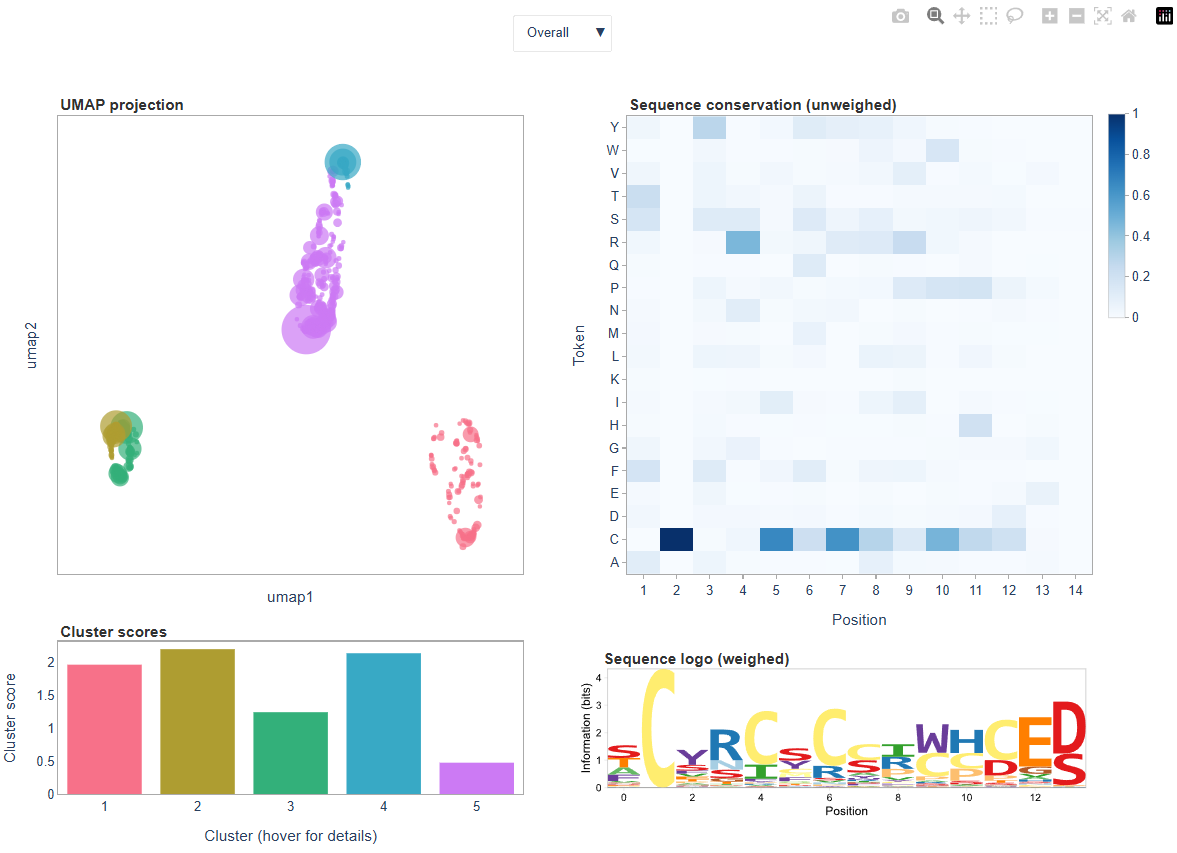

When called with `single_manifold=True`, a combined dashboard showing UMAP projections of all samples in a dataset side by side is created. By default, the process of creating UMAP projections is partially random: repeating it for one dataset produces different projections every time. This means that projections from different samples can not be directly compared to each other by default. For example, one peptide will occupy different regions of the space in each sample. However, it is possible to project (embed) multiple samples in a consistent way, which is what `single_manifold=True` does. The result is that every sequence appears in a fixed place across all samples, which enables direct cross-sample comparisons. This is the primary aim of the `single_manifold=True` keyword. We found it very useful to track the evolution of library composition over multiple rounds of selections with such UMAP projections:

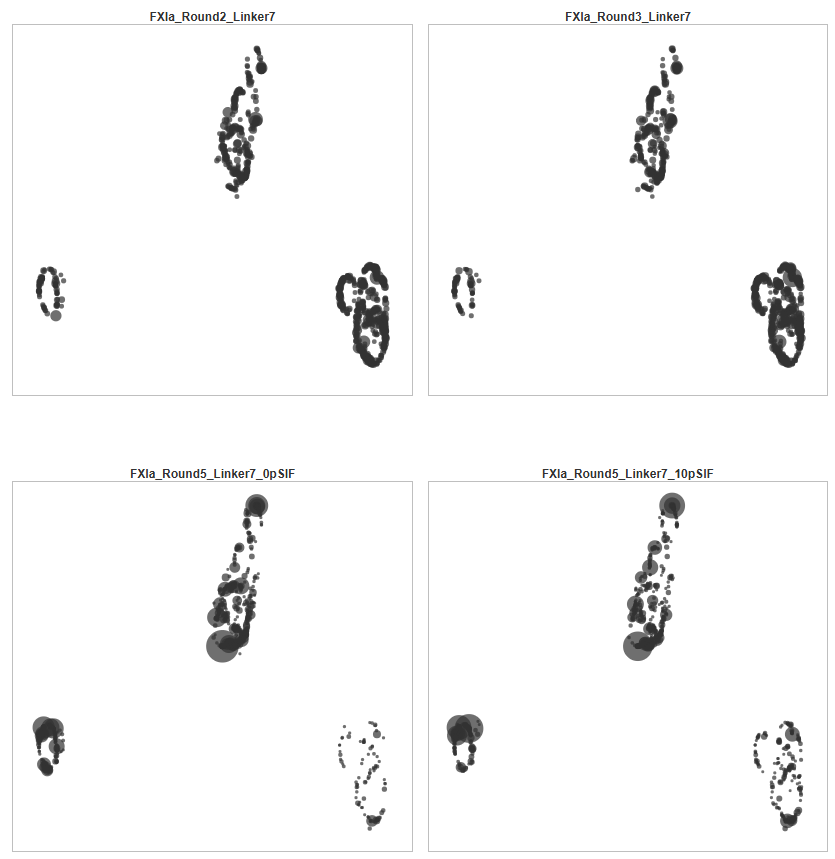

The technique can also be used for DNA sequences if `where='dna'` is specified. 

The resulting embeddings can be extracted if the operation is run with `return_modified=True` keyword.
Samples inside the `data` object will have `Y`, which holds UMAP projection coordinates, as an atrribute:

In [21]:
data

<Data container holding 8 samples>:
<AnalysisSample FXIa_Round2_Linker7 containing 1000 entries>
<AnalysisSample FXIa_Round3_Linker7 containing 1000 entries>
<AnalysisSample FXIa_Round5_Linker7_0pSIF containing 1000 entries>
<AnalysisSample FXIa_Round5_Linker7_10pSIF containing 1000 entries>
<AnalysisSample FXIa_Round5_Linker7_1pSIF containing 1000 entries>
<AnalysisSample FXIa_Round6_Linker7_0pSIF containing 1000 entries>
<AnalysisSample FXIa_Round6_Linker7_10pSIF containing 1000 entries>
<AnalysisSample FXIa_Round6_Linker7_1pSIF containing 1000 entries>

In [29]:
data[0].Y

array([[-0.17979948,  1.2420613 ],
       [ 1.0033212 , -0.48301846],
       [ 0.8761584 , -1.184472  ],
       ...,
       [-0.4822519 ,  0.95126194],
       [-2.2872915 , -0.57900304],
       [-0.2645384 ,  0.6779868 ]], shape=(1000, 2), dtype=float32)

Samples additionally hold `.C` (count) and `.labels` (cluster number) information:

In [30]:
data[0].C[:100]

array([37930, 36013, 22811, 20875, 18939, 15740, 14963, 13732, 13240,
       11569, 10335,  9956,  9399,  9064,  8998,  8862,  8312,  7546,
        7209,  7133,  7065,  6976,  6730,  6729,  6634,  6342,  6130,
        6071,  6064,  5928,  5920,  5881,  5758,  5721,  5698,  5667,
        5531,  5380,  5351,  5343,  5188,  5107,  5062,  5028,  4996,
        4983,  4904,  4678,  4658,  4654,  4602,  4573,  4566,  4558,
        4529,  4484,  4427,  4406,  4377,  4354,  4303,  4293,  4248,
        4215,  4150,  4106,  4104,  4022,  4011,  3950,  3921,  3913,
        3855,  3854,  3767,  3762,  3739,  3711,  3613,  3581,  3577,
        3551,  3488,  3476,  3467,  3412,  3366,  3356,  3325,  3318,
        3299,  3294,  3242,  3213,  3206,  3203,  3194,  3173,  3125,
        3081])

In [31]:
data[0].labels[:100]

array([3, 4, 0, 6, 2, 7, 1, 3, 7, 3, 6, 3, 2, 4, 3, 8, 2, 6, 8, 5, 2, 4,
       1, 6, 5, 8, 5, 3, 5, 8, 2, 7, 5, 7, 4, 5, 4, 3, 3, 3, 5, 3, 8, 3,
       3, 2, 6, 2, 4, 4, 3, 3, 3, 5, 4, 4, 6, 8, 5, 5, 7, 3, 3, 3, 4, 3,
       7, 8, 5, 2, 2, 8, 2, 3, 4, 1, 5, 2, 3, 6, 0, 7, 5, 3, 5, 8, 3, 8,
       6, 4, 3, 2, 3, 5, 6, 3, 5, 3, 5, 4])